# CLARA - Instacart (simple)


Evaluación del número de clusters y ajuste final del modelo. El `k` recomendado se selecciona mediante el mayor coeficiente silhouette.


In [7]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import (
    clara_metrics,
    plot_clustering_metrics,
    analyze_clusters,
    fit_clustering_model,
    save_clustering_metrics,
)
import pandas as pd

## Carga y preparación de los datos


In [8]:
df_scaled = pd.read_csv("../../../scaled_data/instacart_scaled.csv")
df_original = pd.read_csv("../../../simple_datasets/instacart_model_simple.csv")

# Conserva en el escalado solo las variables incluidas en esta versión del dataset.
columnas_modelo = [col for col in df_original.columns if col in df_scaled.columns]
df_scaled_modelo = df_scaled[columnas_modelo].copy()
X = df_scaled_modelo.drop(columns=["user_id"], errors="ignore")

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables de clustering: {X.shape[1]}")
display(X.head())

Observaciones: 206,209
Variables de clustering: 3


,recency,frequency,avg_basket_size
0,-0.286895,-0.070348,-0.578158
1,1.212334,0.316791,0.820566
2,-0.568000,0.138171,-0.236083
3,1.212334,-0.826933,-1.313020
4,-1.036509,-1.054508,0.139108


## Evaluación del número de clusters


In [9]:
resultados_clara = clara_metrics(X)
display(resultados_clara)

,k,silhouette,calinski_harabasz,davies_bouldin,tiempo_segundos
0,2,0.314938,103325.851206,1.298881,0.096487
1,3,0.264185,83066.249663,1.176458,0.098506
2,4,0.309014,100392.355005,1.097605,0.094504
3,5,0.257960,85746.682047,1.201463,0.107178
4,6,0.265600,85092.813271,1.130818,0.107657
5,7,0.231709,79296.265816,1.236678,0.125950
6,8,0.236470,74846.195299,1.169168,0.140978
7,9,0.256820,81128.368637,1.099986,0.133017
8,10,0.242081,74742.602362,1.148776,0.143847


In [ ]:
tabla_metricas = save_clustering_metrics(
    resultados_clara,
    model_name="clara",
    dataset_name="instacart",
    dataset_version="simple",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

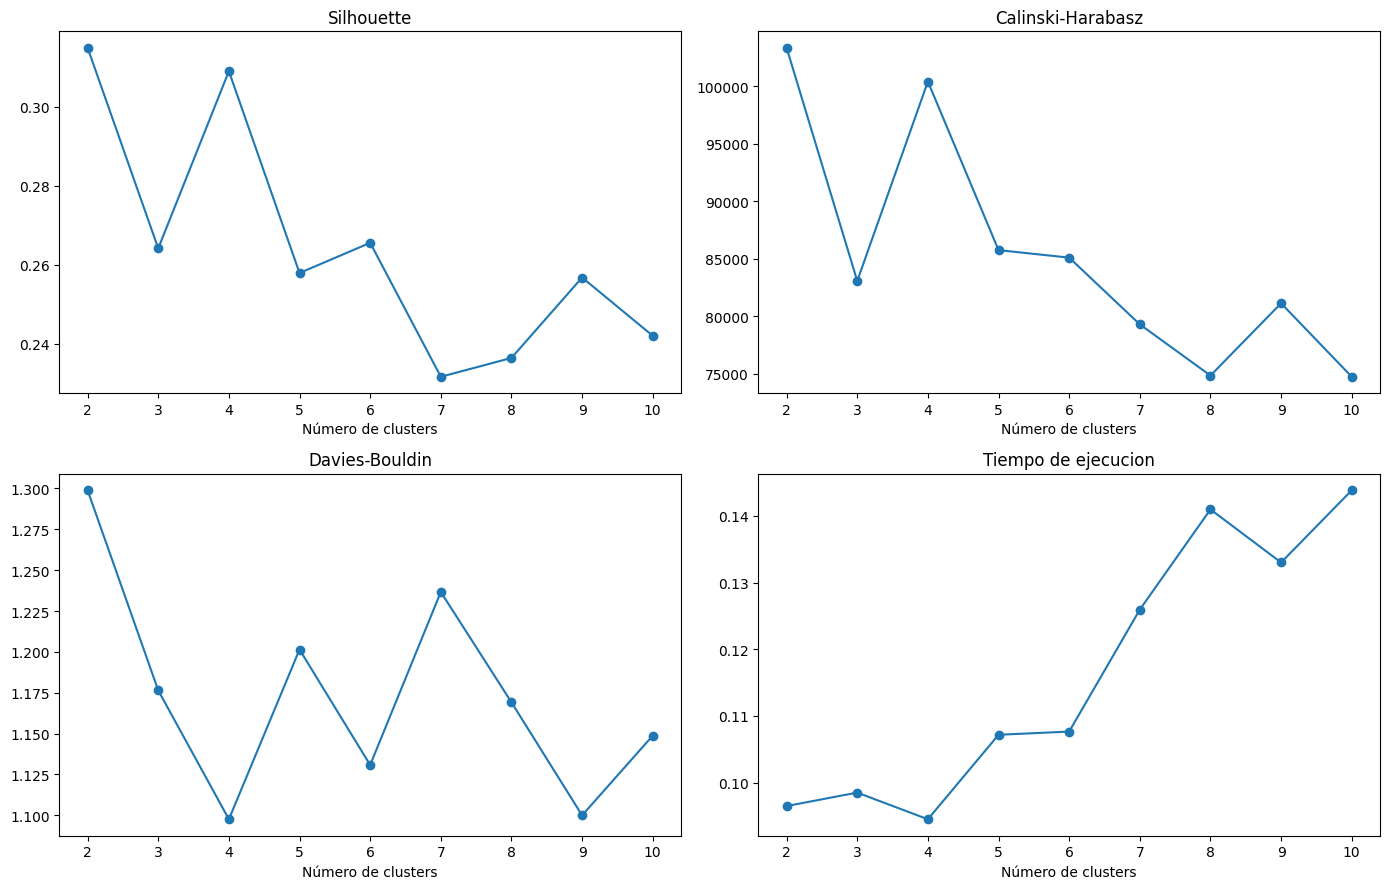

In [10]:
plot_clustering_metrics(
    resultados_clara,
    fourth_metric="tiempo_segundos",
    fourth_title="Tiempo de ejecución",
)

## Ajuste final y perfil de los clusters


In [11]:
modelo, labels = fit_clustering_model(
    model_name="clara",
    k=2,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="user_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


cluster
0     96858
1    109351
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    46.97
1    53.03
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,avg_basket_size
cluster,,,
0,8.301,24.606,11.100
1,24.822,7.604,8.935


- Cluster 0 - Clientes activos y frecuentes (46,97%): muestran baja recencia, alta frecuencia y cestas ligeramente mayores.
- Cluster 1 - Clientes ocasionales y menos recientes (53,03%): realizan pocos pedidos, llevan más tiempo sin comprar y forman cestas algo menores.

In [12]:
modelo, labels = fit_clustering_model(
    model_name="clara",
    k=4,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="user_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


cluster
0    51692
1    37409
2    54195
3    62913
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    25.07
1    18.14
2    26.28
3    30.51
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,avg_basket_size
cluster,,,
0,7.486,7.937,10.836
1,23.662,8.470,3.663
2,9.468,36.678,10.143
3,27.546,7.947,12.800


- Cluster 0 - Clientes recientes de actividad moderada (25,07%): combinan baja recencia con una frecuencia moderada y cestas medias.
- Cluster 1 - Clientes ocasionales de cesta pequeña (18,14%): tienen alta recencia, baja frecuencia y las cestas más pequeñas.
- Cluster 2 - Clientes frecuentes y activos (26,28%): destacan por una frecuencia muy elevada y baja recencia, con cestas medias.
- Cluster 3 - Clientes ocasionales de cesta grande (30,51%): presentan la mayor recencia y baja frecuencia, pero realizan las cestas más grandes.

In [13]:
modelo, labels = fit_clustering_model(
    model_name="clara",
    k=6,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="user_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


cluster
0    27430
1    52354
2    36800
3    30917
4    32478
5    26230
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    13.30
1    25.39
2    17.85
3    14.99
4    15.75
5    12.72
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,avg_basket_size
cluster,,,
0,27.842,5.051,4.244
1,7.377,36.027,9.528
2,25.929,14.735,7.745
3,9.103,9.900,15.530
4,28.324,6.302,15.274
5,8.113,5.230,6.695


- Cluster 0 - Clientes poco activos de cesta pequeña (13,30%): tienen alta recencia, frecuencia muy baja y cestas reducidas.
- Cluster 1 - Clientes frecuentes y activos (25,39%): presentan baja recencia, frecuencia muy elevada y cestas medias.
- Cluster 2 - Clientes menos recientes de actividad intermedia (17,85%): combinan alta recencia con una frecuencia intermedia y cestas moderadas.
- Cluster 3 - Clientes recientes de cesta grande (14,99%): compran recientemente, con frecuencia moderada y cestas muy grandes.
- Cluster 4 - Clientes ocasionales de cesta grande (15,75%): muestran alta recencia y baja frecuencia, aunque realizan cestas muy grandes.
- Cluster 5 - Clientes recientes de baja intensidad (12,72%): presentan baja recencia, poca frecuencia y cestas pequeñas.